In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score

In [2]:
# Load the dataset
df = pd.read_csv('placement.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())

Dataset shape: (100, 3)

First few rows:
   cgpa   iq  placement
0   6.8  123          1
1   5.9  106          0
2   5.3  121          0
3   7.4  132          1
4   5.8  142          0

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    int64  
 2   placement  100 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 2.5 KB
None


In [3]:
# Prepare features and target
# Using CGPA and IQ as features to predict placement
X = df[['cgpa', 'iq']].values
y = df['placement'].values

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (100, 2)
Target (y) shape: (100,)


In [4]:
# Split the dataset into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 80
Test set size: 20


In [5]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [6]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# For F2-Score, convert predictions to binary (0 or 1)
y_pred_binary = (y_pred >= 0.5).astype(int)
f2 = f1_score(y_test, y_pred_binary, average='binary')

print("=== Evaluation Metrics ===")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"F2-Score: {f2:.4f}")

=== Evaluation Metrics ===
Mean Squared Error (MSE): 0.0893
Mean Absolute Error (MAE): 0.2328
F2-Score: 0.8421


In [7]:
# Test with real data
print("=== Testing with Real Data ===")
print("\nSample predictions on test set:")
for i in range(min(5, len(X_test))):
    print(f"CGPA: {X_test[i][0]:.1f}, IQ: {X_test[i][1]:.0f} -> Predicted: {y_pred[i]:.2f}, Actual: {y_test[i]}")

=== Testing with Real Data ===

Sample predictions on test set:
CGPA: 7.5, IQ: 130 -> Predicted: 1.07, Actual: 1
CGPA: 8.3, IQ: 168 -> Predicted: 1.40, Actual: 1
CGPA: 6.3, IQ: 127 -> Predicted: 0.62, Actual: 1
CGPA: 6.0, IQ: 66 -> Predicted: 0.45, Actual: 1
CGPA: 7.5, IQ: 61 -> Predicted: 1.00, Actual: 1


In [8]:
# Print coefficients and intercept
print("=== Model Parameters ===")
print(f"Coefficients: {model.coef_}")
print(f"  - CGPA coefficient: {model.coef_[0]:.4f}")
print(f"  - IQ coefficient: {model.coef_[1]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"\nRegression equation: y = {model.intercept_:.4f} + {model.coef_[0]:.4f}*CGPA + {model.coef_[1]:.4f}*IQ")

=== Model Parameters ===
Coefficients: [0.37379696 0.0009817 ]
  - CGPA coefficient: 0.3738
  - IQ coefficient: 0.0010
Intercept: -1.8625

Regression equation: y = -1.8625 + 0.3738*CGPA + 0.0010*IQ


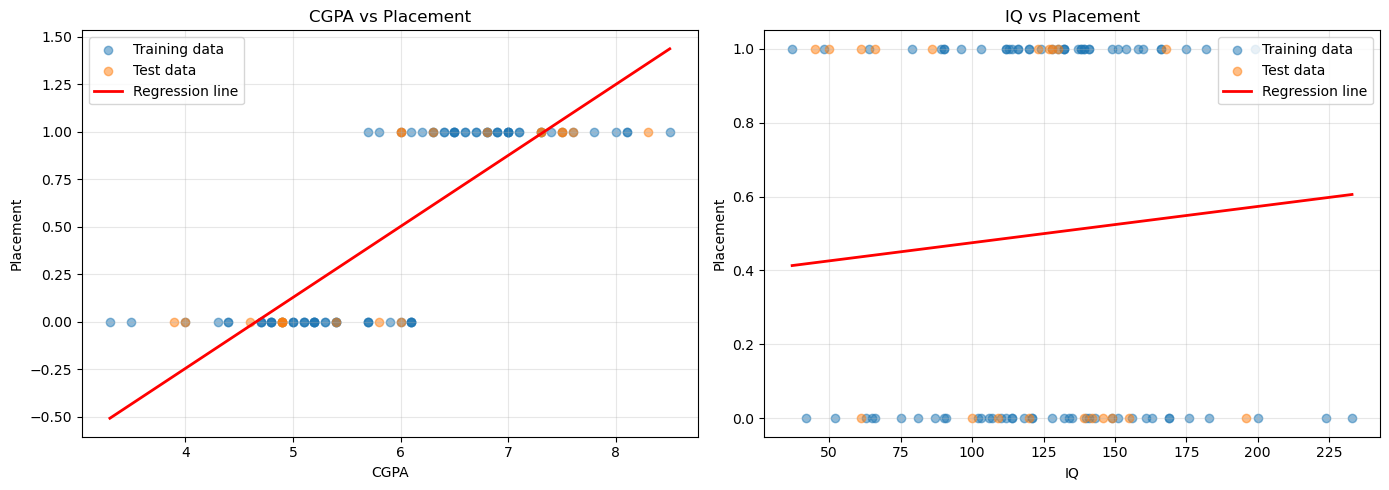

In [9]:
# Plot input features and regression line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: CGPA vs Placement
axes[0].scatter(X_train[:, 0], y_train, alpha=0.5, label='Training data')
axes[0].scatter(X_test[:, 0], y_test, alpha=0.5, label='Test data')
# Plot regression line for CGPA (keeping IQ at its mean)
cgpa_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
iq_mean = X[:, 1].mean()
predictions = model.predict(np.column_stack([cgpa_range, np.full(100, iq_mean)]))
axes[0].plot(cgpa_range, predictions, 'r-', linewidth=2, label='Regression line')
axes[0].set_xlabel('CGPA')
axes[0].set_ylabel('Placement')
axes[0].set_title('CGPA vs Placement')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: IQ vs Placement
axes[1].scatter(X_train[:, 1], y_train, alpha=0.5, label='Training data')
axes[1].scatter(X_test[:, 1], y_test, alpha=0.5, label='Test data')
# Plot regression line for IQ (keeping CGPA at its mean)
iq_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
cgpa_mean = X[:, 0].mean()
predictions = model.predict(np.column_stack([np.full(100, cgpa_mean), iq_range]))
axes[1].plot(iq_range, predictions, 'r-', linewidth=2, label='Regression line')
axes[1].set_xlabel('IQ')
axes[1].set_ylabel('Placement')
axes[1].set_title('IQ vs Placement')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Performance Discussion

### Observations:
1. **MSE and MAE**: These metrics show how far our predictions are from actual values. Lower values indicate better performance.

2. **F2-Score**: This metric evaluates the model's classification ability when we convert continuous predictions to binary (placed/not placed). A score closer to 1 indicates better classification.

3. **Model Characteristics**:
   - This is a **linear regression** model predicting placement (0 or 1) using CGPA and IQ as features
   - The coefficients show how much each feature contributes to the prediction
   - A positive coefficient means higher values of that feature increase placement probability

4. **Limitations**:
   - Linear regression for binary classification may produce predictions outside [0, 1] range
   - The model assumes a linear relationship between features and placement
   - Logistic regression would be more suitable for binary classification problems

5. **Strengths**:
   - Simple and interpretable
   - Fast to train and predict
   - Provides clear understanding of feature importance through coefficients